# Notebook 05 — Signal Performance Metrics and Evaluation Framework

## Objective
Develop an intersection-level evaluation framework that summarizes traffic pressure, demand intensity, and candidate signal priorities in a form suitable for later timing analysis.

## Dataset / Inputs
This notebook uses the engineered traffic-signal dataset and filters to valid signalized matches. The resulting performance summaries are saved for ranking intersections and supporting strategy comparisons.

## Methodology
The analysis validates required fields, computes intersection-level metrics, interprets their operational meaning, ranks candidate locations, and visualizes the resulting distribution of traffic-performance indicators.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
from IPython.display import Markdown, display


## Load Dataset

Load the processed signal optimization feature dataset, parse the date field, and confirm the overall structure before computing any metrics.

In [2]:
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

input_path = project_root / 'data/processed/signal_optimization_features_2015_2019.csv'
output_path = project_root / 'data/processed/signal_performance_metrics_2015_2019.csv'

if not input_path.exists():
    raise FileNotFoundError(f'Input dataset not found: {input_path}')

df_raw = pd.read_csv(input_path, parse_dates=['date'])

print(f'Loaded data from: {input_path.relative_to(project_root)}')
print(f'Dataset shape: {df_raw.shape}')

df_raw.head()

Loaded data from: data/processed/signal_optimization_features_2015_2019.csv
Dataset shape: (138672, 36)


,location_id,location_name,centreline_id,direction,date,hour,traffic_latitude,traffic_longitude,nearest_signal_id,nearest_signal_name,nearest_signal_latitude,nearest_signal_longitude,distance_to_signal_m,is_signalized_match,year,month,quarter,day_of_week,is_weekend,hour_of_day,AM_peak_flag,PM_peak_flag,daily_total_volume,hourly_volume,peak_hour_volume,peak_ratio,hourly_share_of_daily_volume,normalized_demand_intensity,estimated_arrival_rate_vph,approach_demand_proxy,directional_imbalance,green_split_weight_proxy,critical_flow_proxy,saturation_proxy,is_peak_hour,observed_hour_count
0,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 00:00:00,43.681,-79.336,"10,010,625.000",DANFORTH AVE / DONLANDS AVE,43.680,-79.337,82.781,True,2015,5,2,3,0,0,0,0,17031,286,1809,0.106,0.017,0.513,286,286,1.000,0.017,0.158,0.158,0,24
1,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 01:00:00,43.681,-79.336,"10,010,625.000",DANFORTH AVE / DONLANDS AVE,43.680,-79.337,82.781,True,2015,5,2,3,0,1,0,0,17031,198,1809,0.106,0.012,0.355,198,198,1.000,0.012,0.109,0.109,0,24
2,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 02:00:00,43.681,-79.336,"10,010,625.000",DANFORTH AVE / DONLANDS AVE,43.680,-79.337,82.781,True,2015,5,2,3,0,2,0,0,17031,134,1809,0.106,0.008,0.240,134,134,1.000,0.008,0.074,0.074,0,24
3,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 03:00:00,43.681,-79.336,"10,010,625.000",DANFORTH AVE / DONLANDS AVE,43.680,-79.337,82.781,True,2015,5,2,3,0,3,0,0,17031,118,1809,0.106,0.007,0.211,118,118,1.000,0.007,0.065,0.065,0,24
4,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 04:00:00,43.681,-79.336,"10,010,625.000",DANFORTH AVE / DONLANDS AVE,43.680,-79.337,82.781,True,2015,5,2,3,0,4,0,0,17031,131,1809,0.106,0.008,0.235,131,131,1.000,0.008,0.072,0.072,0,24


## Validate Required Columns

The notebook uses explicit, project-relevant columns for signal mapping, hourly demand, and temporal aggregation. A clear error is raised if any required field is missing.

In [3]:
required_columns = [
    'nearest_signal_id',
    'distance_to_signal_m',
    'is_signalized_match',
    'hourly_volume',
    'date',
]

optional_name_column = 'nearest_signal_name'
optional_hour_columns = ['hour_of_day', 'hour']

missing_columns = [column for column in required_columns if column not in df_raw.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

available_optional_hour_columns = [column for column in optional_hour_columns if column in df_raw.columns]
if not available_optional_hour_columns:
    raise ValueError('At least one hour-level field is required: hour_of_day or hour.')

validated_columns = required_columns + [column for column in [optional_name_column, *available_optional_hour_columns] if column in df_raw.columns]
print('Validated columns:')
for column in validated_columns:
    print(f' - {column}')

Validated columns:
 - nearest_signal_id
 - distance_to_signal_m
 - is_signalized_match
 - hourly_volume
 - date
 - nearest_signal_name
 - hour_of_day
 - hour


## Filter Valid Signalized Matches

Only matched records are retained so the analysis reflects intersections that were successfully linked to Toronto signal infrastructure.

In [4]:
df = df_raw.loc[df_raw['is_signalized_match']].copy()

if df.empty:
    raise ValueError('No valid signalized matches were found after filtering.')

df['nearest_signal_id'] = df['nearest_signal_id'].astype('Int64')
df['signal_label'] = np.where(
    df['nearest_signal_name'].notna() & df['nearest_signal_name'].astype(str).str.strip().ne(''),
    df['nearest_signal_name'].astype(str),
    'Signal ' + df['nearest_signal_id'].astype(str),
)
df['analysis_date'] = df['date'].dt.normalize()

print(f'Retained rows: {len(df):,}')
print(f'Unique matched intersections: {df["nearest_signal_id"].nunique():,}')
print(f'Mean match distance (m): {df["distance_to_signal_m"].mean():,.2f}')

Retained rows: 108,696
Unique matched intersections: 357
Mean match distance (m): 66.97


## Compute Intersection-Level Traffic Metrics

Metrics are aggregated at the signalized intersection level. These indicators are demand-based proxies that help identify where signal timing improvements may matter most in later optimization stages.

In [5]:
group_columns = ['nearest_signal_id']
if 'nearest_signal_name' in df.columns:
    group_columns.append('nearest_signal_name')

metrics = (
    df.groupby(group_columns, dropna=False)
      .agg(
          avg_hourly_volume=('hourly_volume', 'mean'),
          peak_hour_volume=('hourly_volume', 'max'),
          min_hourly_volume=('hourly_volume', 'min'),
          hourly_volume_std=('hourly_volume', 'std'),
          observation_count=('hourly_volume', 'size'),
          avg_match_distance_m=('distance_to_signal_m', 'mean'),
          active_days=('analysis_date', 'nunique'),
          avg_daily_volume=('daily_total_volume', 'mean'),
      )
      .reset_index()
)

metrics['hourly_volume_std'] = metrics['hourly_volume_std'].fillna(0.0)

network_average_hourly_volume = metrics['avg_hourly_volume'].mean()
network_average_peak_volume = metrics['peak_hour_volume'].mean()

metrics['peak_to_average_ratio'] = np.where(
    metrics['avg_hourly_volume'] > 0,
    metrics['peak_hour_volume'] / metrics['avg_hourly_volume'],
    np.nan,
)
metrics['traffic_variability_index'] = np.where(
    metrics['avg_hourly_volume'] > 0,
    metrics['hourly_volume_std'] / metrics['avg_hourly_volume'],
    np.nan,
)
metrics['intersection_load_index'] = np.where(
    network_average_hourly_volume > 0,
    metrics['avg_hourly_volume'] / network_average_hourly_volume,
    np.nan,
)
metrics['peak_load_index'] = np.where(
    network_average_peak_volume > 0,
    metrics['peak_hour_volume'] / network_average_peak_volume,
    np.nan,
)

metrics = metrics.sort_values(['intersection_load_index', 'peak_hour_volume'], ascending=[False, False]).reset_index(drop=True)

print(f'Aggregated intersections: {len(metrics):,}')
metrics.head()

Aggregated intersections: 357


,nearest_signal_id,nearest_signal_name,avg_hourly_volume,peak_hour_volume,min_hourly_volume,hourly_volume_std,observation_count,avg_match_distance_m,active_days,avg_daily_volume,peak_to_average_ratio,traffic_variability_index,intersection_load_index,peak_load_index
0,436631,YONGE ST / STEELES AVE,"1,294.993",2418,80,706.181,144,46.100,3,"31,079.833",1.867,0.545,2.844,2.113
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,"1,231.190",2621,82,761.432,168,79.226,7,"29,548.571",2.129,0.618,2.704,2.290
2,3327208,STEELES AVE W / DUFFERIN ST,"1,046.382",2249,63,589.738,144,2.683,3,"25,113.167",2.149,0.564,2.298,1.965
3,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,"1,035.729",2447,81,653.097,144,91.085,3,"24,857.500",2.363,0.631,2.275,2.138
4,913150,DUNDAS ST W / NEILSON DR / WEST MALL CRES,"1,004.210",2290,50,659.397,480,58.127,10,"24,101.050",2.280,0.657,2.205,2.001


## Evaluation Interpretation

These metrics are designed as **evaluation inputs** for future baseline-versus-optimized comparisons:

- Higher **average hourly volume** suggests sustained demand and persistent operational importance.
- Higher **peak-to-average ratio** suggests sharper surge periods and stronger peak pressure.
- Higher **traffic variability index** suggests less stable demand and potentially greater control complexity.
- Higher **intersection load index** suggests a stronger relative priority for optimization within the wider network.

These are not direct measures of delay, queue length, or level of service. Instead, they serve as transparent, defensible demand-side indicators for later signal optimization analysis.

## Rank Candidate Intersections

The following ranked views highlight intersections that stand out under different evaluation criteria.

In [6]:
rank_columns = ['nearest_signal_id']
if 'nearest_signal_name' in metrics.columns:
    rank_columns.append('nearest_signal_name')

ranking_specs = {
    'Top intersections by average hourly volume': 'avg_hourly_volume',
    'Top intersections by peak hour volume': 'peak_hour_volume',
    'Top intersections by peak-to-average ratio': 'peak_to_average_ratio',
    'Top intersections by intersection load index': 'intersection_load_index',
}

for title, metric_column in ranking_specs.items():
    print()
    print(title)
    display(metrics.nlargest(10, metric_column)[rank_columns + [metric_column]])


Top intersections by average hourly volume


,nearest_signal_id,nearest_signal_name,avg_hourly_volume
0,436631,YONGE ST / STEELES AVE,"1,294.993"
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,"1,231.190"
2,3327208,STEELES AVE W / DUFFERIN ST,"1,046.382"
3,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,"1,035.729"
4,913150,DUNDAS ST W / NEILSON DR / WEST MALL CRES,"1,004.210"
5,106625,MCCOWAN RD / PITFIELD RD / INVERGORDON AVE,988.604
6,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,965.312
7,907862,REXDALE BLVD / HUMBERWOOD BLVD,921.125
8,9344974,SHEPPARD AVE E / MCCOWAN RD,910.786
9,436346,STEELES AVE E / BAYVIEW AVE,903.562



Top intersections by peak hour volume


,nearest_signal_id,nearest_signal_name,peak_hour_volume
6,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,3047
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,2621
21,4223571,STEELES AVE E / MARKHAM RD,2529
3,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,2447
0,436631,YONGE ST / STEELES AVE,2418
17,6345158,UNIVERSITY AVE / COLLEGE ST,2365
18,912255,BURNHAMTHORPE RD / MILL RD,2317
4,913150,DUNDAS ST W / NEILSON DR / WEST MALL CRES,2290
2,3327208,STEELES AVE W / DUFFERIN ST,2249
95,4417422,KINGSTON RD / PORT UNION RD / SHEPPARD AVE E,2239



Top intersections by peak-to-average ratio


,nearest_signal_id,nearest_signal_name,peak_to_average_ratio
354,103008,OLD FINCH AVE / SEWELLS RD / 250m EAST OF,7.823
335,2735476,KINGSTON RD / DUNDAS ST E / DIXON AVE,7.459
332,12047979,SHEPPARD AVE E / WILLOWDALE AVE,6.289
339,30039607,CHRISTIE ST / BARTON AVE,6.233
275,4429233,FINCH AVE E / PHARMACY AVE,5.221
342,1142745,BATHURST ST / BARTON AVE,5.209
188,1142152,QUEEN ST E / WOODBINE AVE,4.778
301,9311781,PHARMACY AVE / MCNICOLL AVE,4.602
257,14023125,BROADVIEW AVE / DUNDAS ST E,4.486
196,5503138,EGLINTON AVE W / RENFORTH DR,4.365



Top intersections by intersection load index


,nearest_signal_id,nearest_signal_name,intersection_load_index
0,436631,YONGE ST / STEELES AVE,2.844
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,2.704
2,3327208,STEELES AVE W / DUFFERIN ST,2.298
3,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,2.275
4,913150,DUNDAS ST W / NEILSON DR / WEST MALL CRES,2.205
5,106625,MCCOWAN RD / PITFIELD RD / INVERGORDON AVE,2.171
6,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,2.120
7,907862,REXDALE BLVD / HUMBERWOOD BLVD,2.023
8,9344974,SHEPPARD AVE E / MCCOWAN RD,2.000
9,436346,STEELES AVE E / BAYVIEW AVE,1.984


## Create Visualizations

These plots summarize the distribution of demand indicators across matched signalized intersections and highlight the strongest candidates for future optimization analysis.

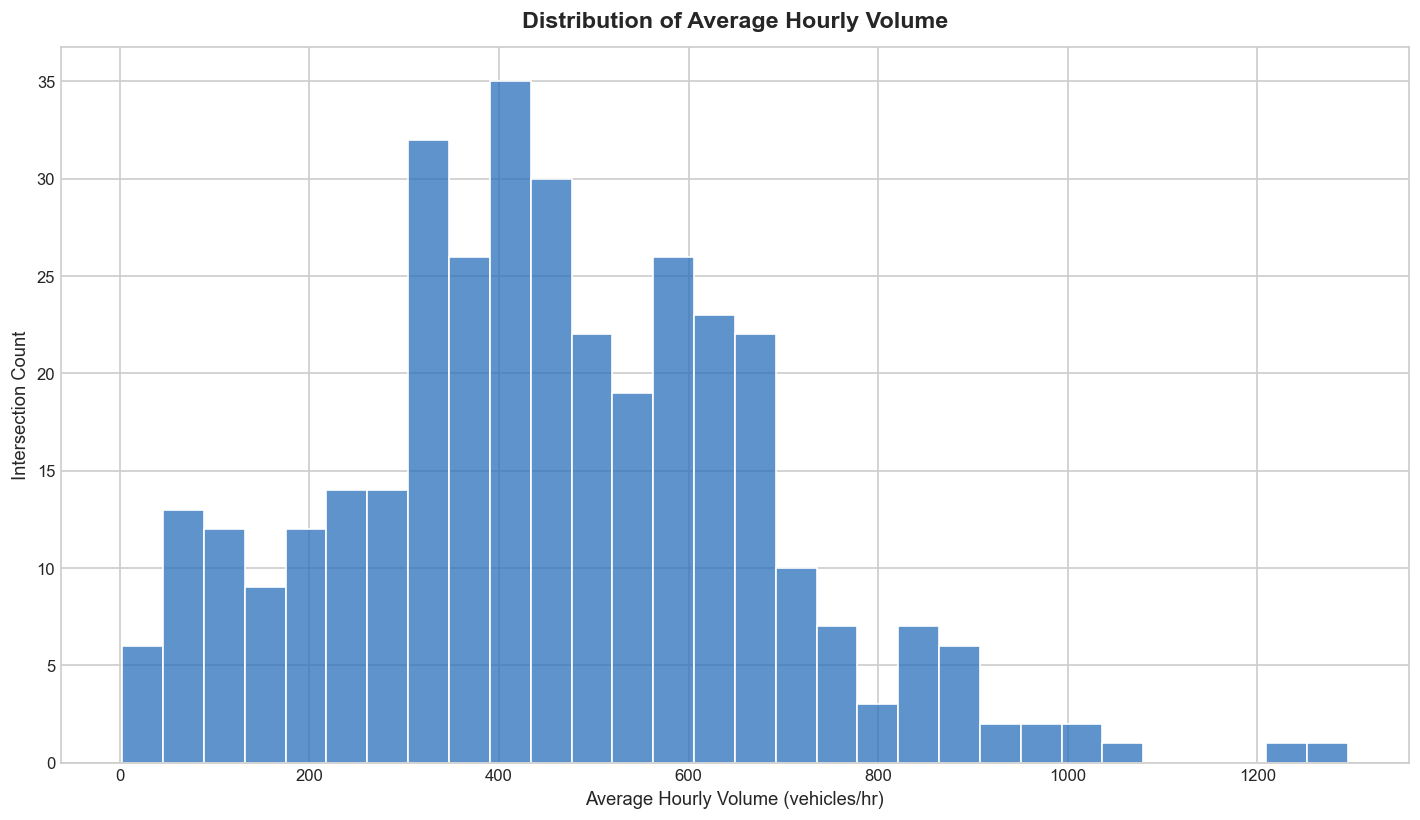

### Visual Description
This histogram shows how average hourly traffic volume is distributed across intersections. The x-axis reports average vehicles per hour and the y-axis reports the number of intersections.

### Insight
The distribution highlights overall load heterogeneity in the network. Intersections in the high-volume tail are stronger candidates for congestion-focused interventions.

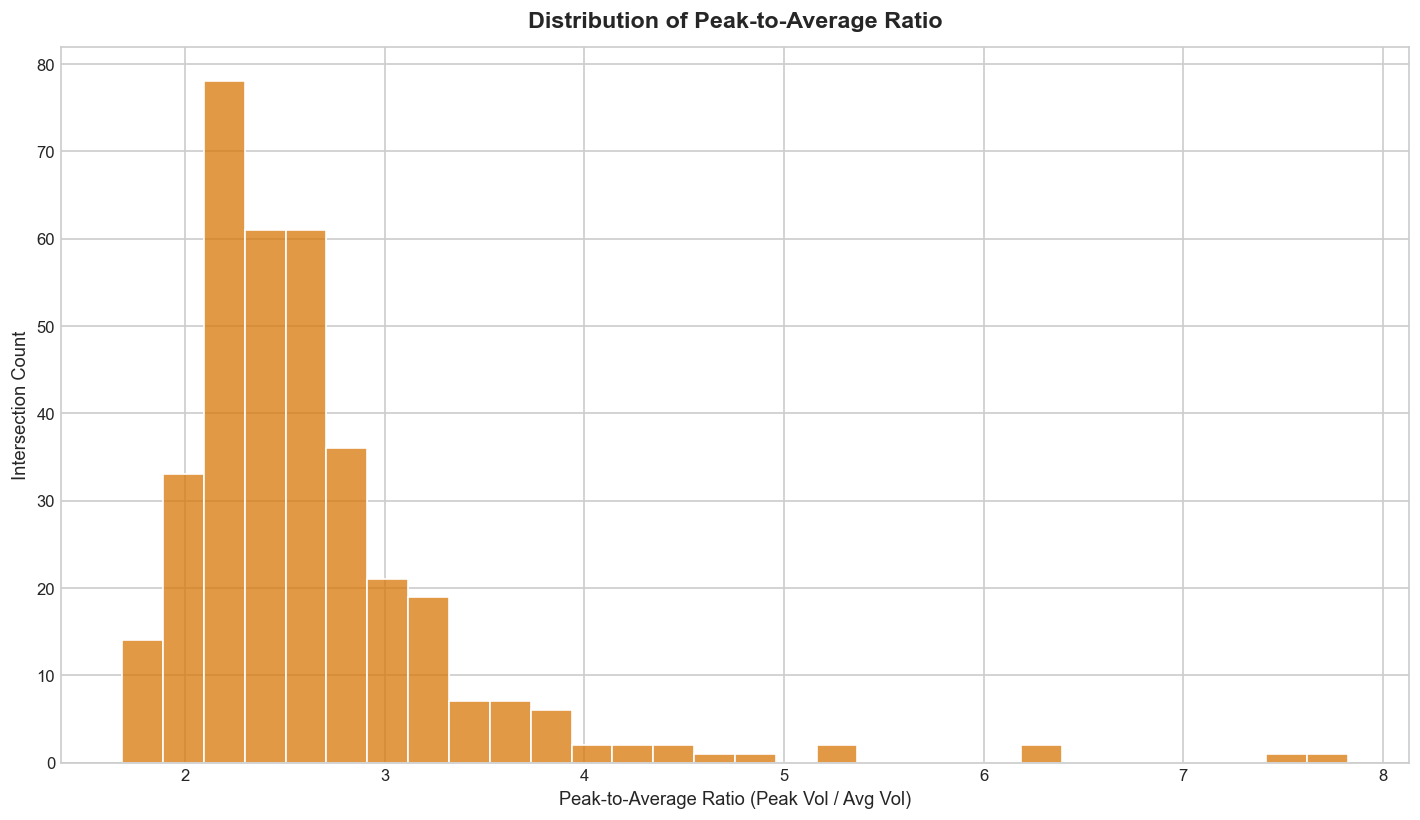

### Visual Description
This histogram shows the distribution of peak-to-average ratio across intersections, where the ratio compares peak-hour volume to average hourly volume.

### Insight
Higher ratios indicate stronger demand concentration in short windows, which signals volatility and operational stress during rush periods.

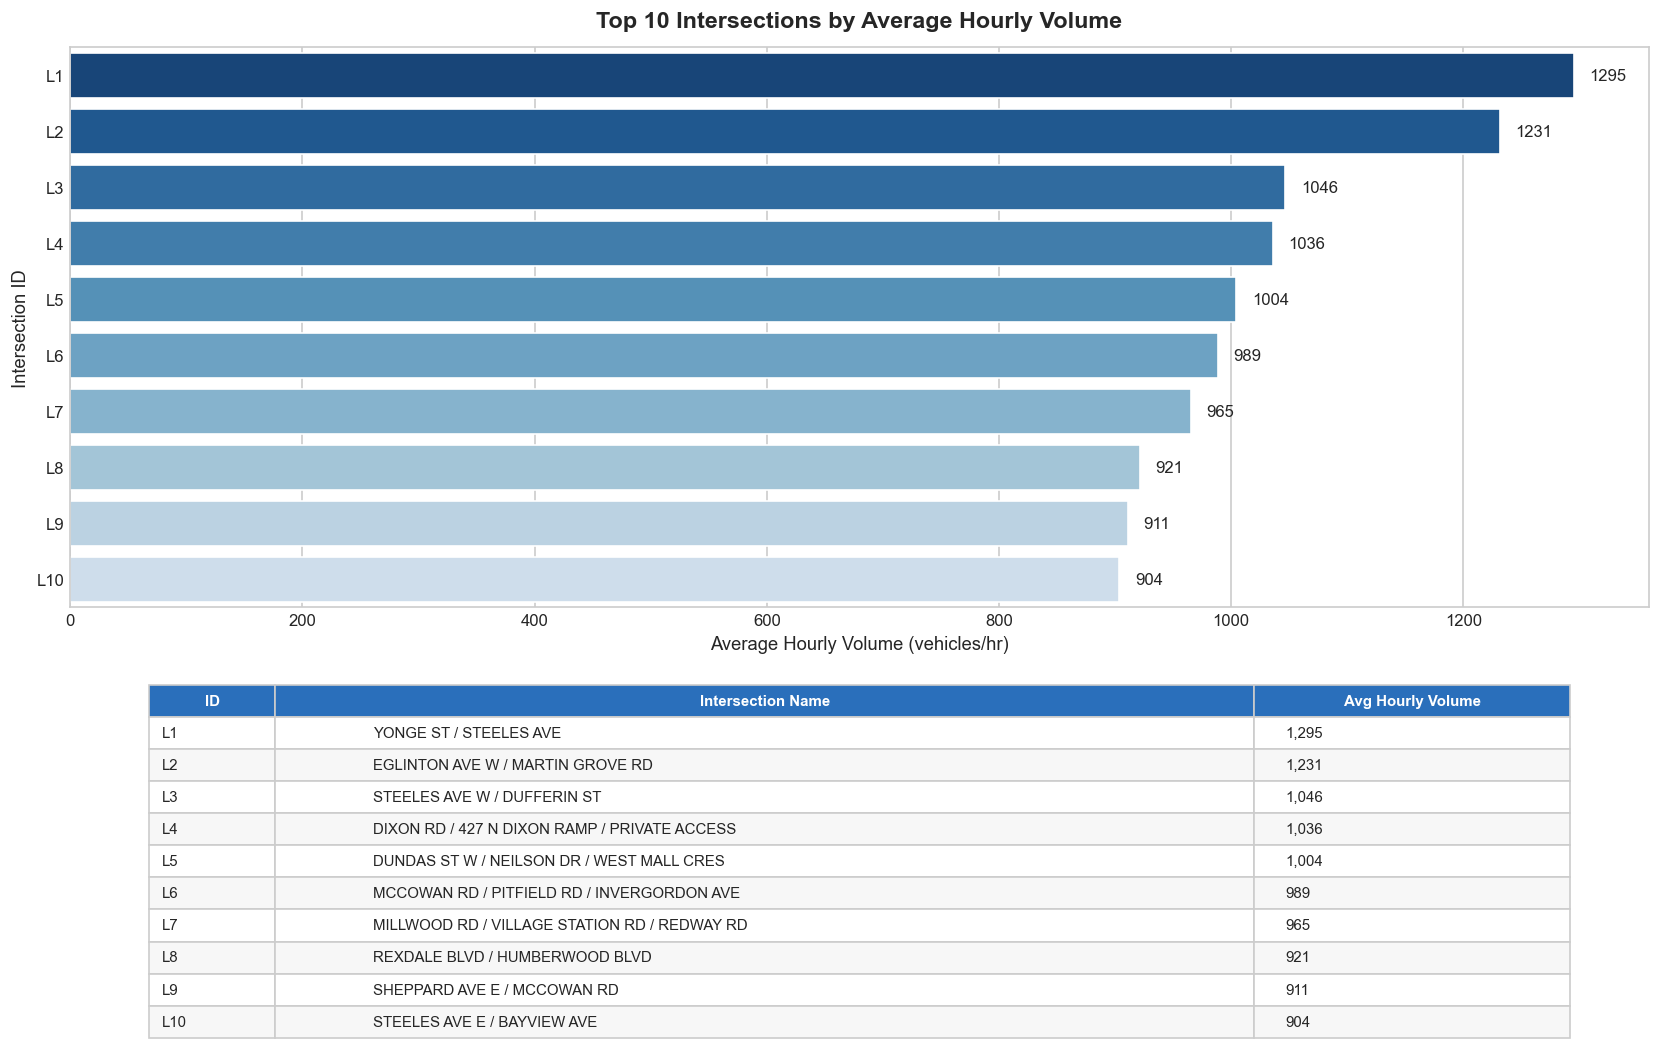

### Visual Description
This ranked bar chart displays the top ten intersections by average hourly volume, with IDs (L1-L10) mapped to intersection names in the table below.

### Insight
The chart identifies consistently high-load intersections that may require sustained capacity and timing improvements beyond peak-only treatment.

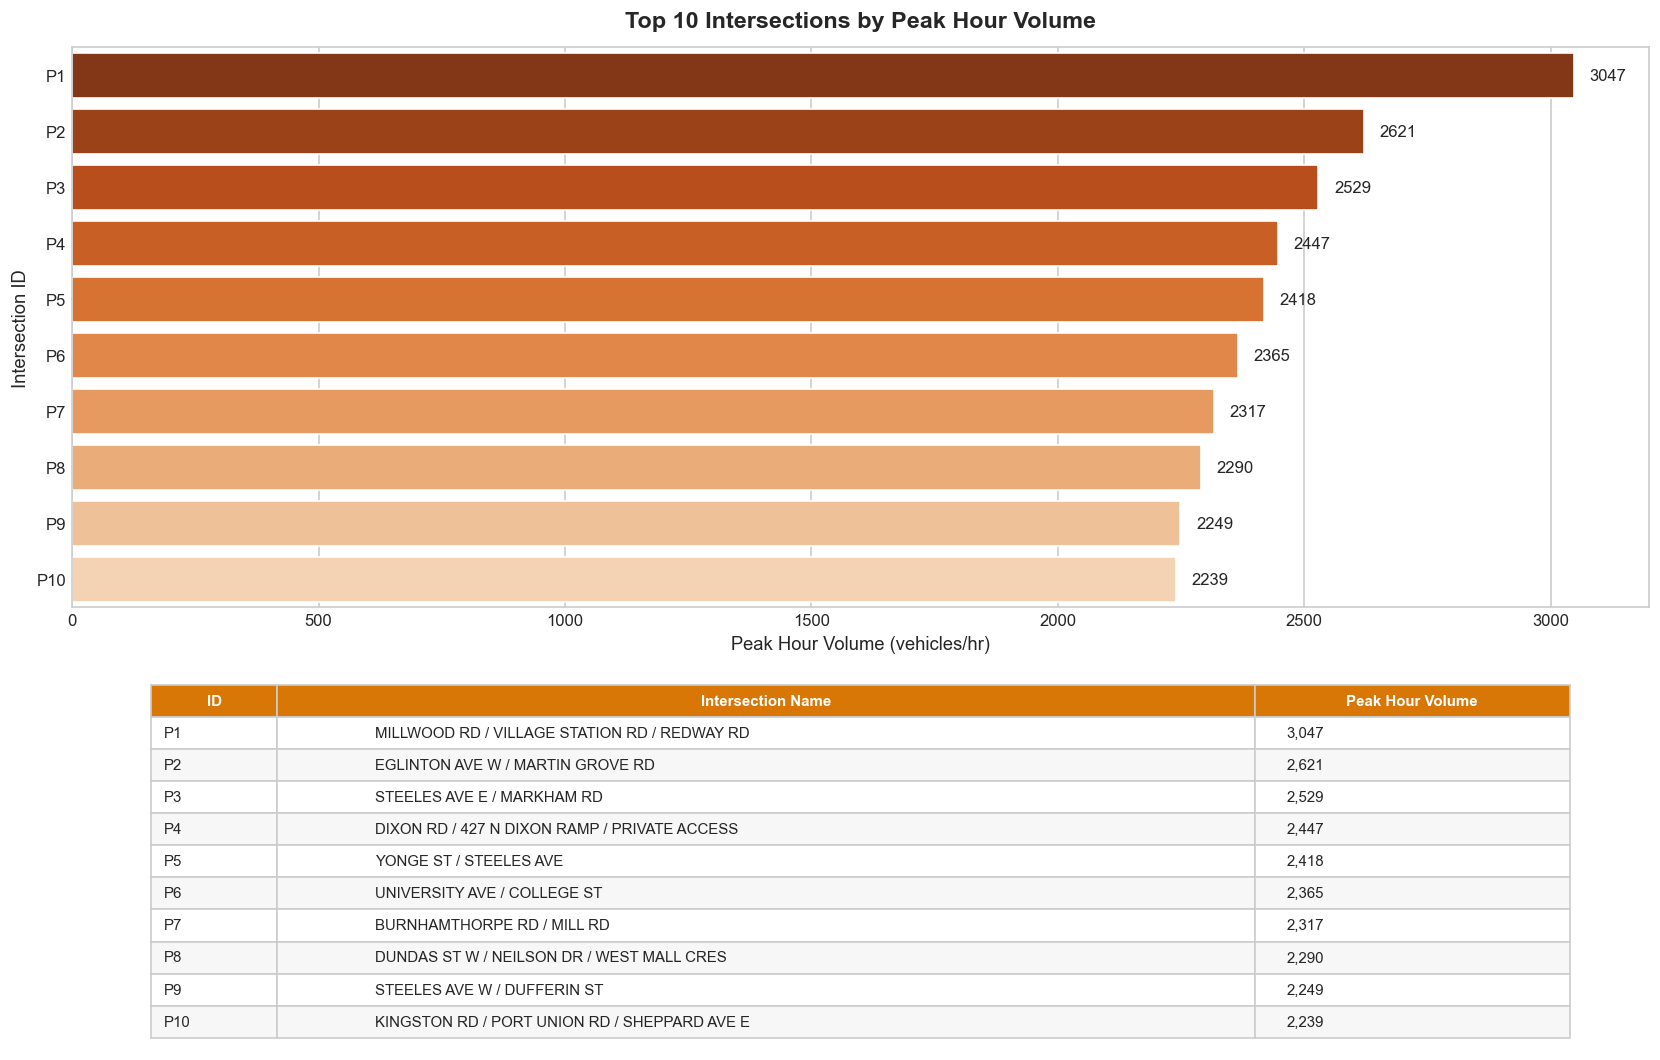

### Visual Description
This ranked bar chart shows the top ten intersections by peak-hour volume, with coded labels (P1-P10) and a name-mapping table.

### Insight
These locations represent the strongest peak demand pressure points and are priority targets for peak-period signal optimization.

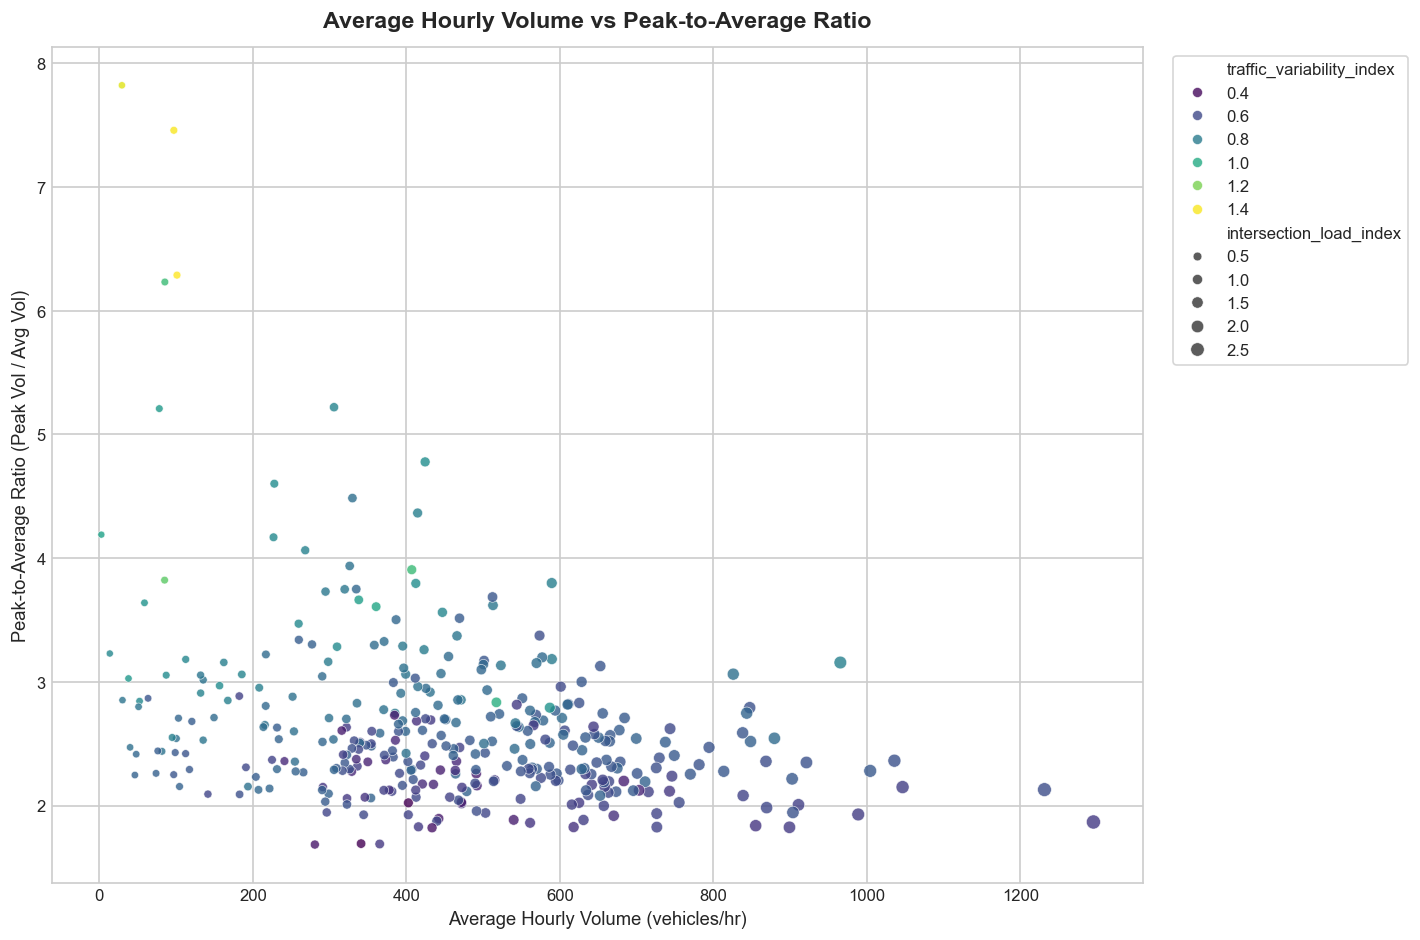

### Visual Description
This scatter plot compares average hourly volume and peak-to-average ratio, while marker size reflects load index and color reflects variability index.

### Insight
The relationship separates consistently busy intersections from highly variable ones, supporting more nuanced prioritization for congestion forecasting and control.

In [7]:
def add_bar_labels(ax, fmt="{:.0f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width + (ax.get_xlim()[1] * 0.01), y, fmt.format(width), va="center", fontsize=10)


def add_visual_note(description: str, insight: str) -> None:
    display(Markdown("### Visual Description\n" + description + "\n\n### Insight\n" + insight))

# -- 1. Distribution of Average Hourly Volume --
plt.figure(figsize=(12, 7))
ax1 = sns.histplot(data=metrics, x="avg_hourly_volume", bins=30, color="#2a6fbb", edgecolor="white")
ax1.set_title("Distribution of Average Hourly Volume", pad=12, fontsize=14, fontweight="bold")
ax1.set_xlabel("Average Hourly Volume (vehicles/hr)")
ax1.set_ylabel("Intersection Count")
plt.tight_layout()
plt.show()
add_visual_note('This histogram shows how average hourly traffic volume is distributed across intersections. The x-axis reports average vehicles per hour and the y-axis reports the number of intersections.', 'The distribution highlights overall load heterogeneity in the network. Intersections in the high-volume tail are stronger candidates for congestion-focused interventions.')

# -- 2. Distribution of Peak-to-Average Ratio --
plt.figure(figsize=(12, 7))
ax2 = sns.histplot(data=metrics, x="peak_to_average_ratio", bins=30, color="#d97706", edgecolor="white")
ax2.set_title("Distribution of Peak-to-Average Ratio", pad=12, fontsize=14, fontweight="bold")
ax2.set_xlabel("Peak-to-Average Ratio (Peak Vol / Avg Vol)")
ax2.set_ylabel("Intersection Count")
plt.tight_layout()
plt.show()
add_visual_note('This histogram shows the distribution of peak-to-average ratio across intersections, where the ratio compares peak-hour volume to average hourly volume.', 'Higher ratios indicate stronger demand concentration in short windows, which signals volatility and operational stress during rush periods.')

# -- 3. Top 10 Intersections by Average Hourly Volume --
avg_top_10 = metrics.nlargest(10, "avg_hourly_volume").sort_values("avg_hourly_volume", ascending=False).reset_index(drop=True)
avg_colors = sns.color_palette("Blues", n_colors=len(avg_top_10) + 2)[2:][::-1]
avg_short_labels = [f"L{i+1}" for i in range(len(avg_top_10))]

fig3, (ax3_chart, ax3_tbl) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 2]}, tight_layout=True)

sns.barplot(
    data=avg_top_10, x="avg_hourly_volume", y="nearest_signal_name",
    hue="nearest_signal_name", palette=avg_colors, dodge=False, legend=False, ax=ax3_chart
)
ax3_chart.set_yticks(range(len(avg_short_labels)))
ax3_chart.set_yticklabels(avg_short_labels)
ax3_chart.set_title("Top 10 Intersections by Average Hourly Volume", pad=12, fontsize=14, fontweight="bold")
ax3_chart.set_xlabel("Average Hourly Volume (vehicles/hr)")
ax3_chart.set_ylabel("Intersection ID")
add_bar_labels(ax3_chart)

ax3_tbl.axis("off")
avg_table_data = [[avg_short_labels[i], avg_top_10.loc[i, "nearest_signal_name"], f"{avg_top_10.loc[i, 'avg_hourly_volume']:,.0f}"] for i in range(len(avg_short_labels))]
tbl3 = ax3_tbl.table(
    cellText=avg_table_data, colLabels=["ID", "Intersection Name", "Avg Hourly Volume"],
    loc="center", cellLoc="left", colWidths=[0.08, 0.62, 0.20]
)
tbl3.auto_set_font_size(False)
tbl3.set_fontsize(9)
tbl3.scale(1, 1.3)
for (row, col), tcell in tbl3.get_celld().items():
    tcell.set_edgecolor("#cccccc")
    if row == 0:
        tcell.set_facecolor("#2a6fbb")
        tcell.set_text_props(color="white", fontweight="bold")
    else:
        tcell.set_facecolor("#f7f7f7" if row % 2 == 0 else "white")
plt.show()
add_visual_note('This ranked bar chart displays the top ten intersections by average hourly volume, with IDs (L1-L10) mapped to intersection names in the table below.', 'The chart identifies consistently high-load intersections that may require sustained capacity and timing improvements beyond peak-only treatment.')

# -- 4. Top 10 Intersections by Peak Hour Volume --
peak_top_10 = metrics.nlargest(10, "peak_hour_volume").sort_values("peak_hour_volume", ascending=False).reset_index(drop=True)
peak_colors = sns.color_palette("Oranges", n_colors=len(peak_top_10) + 2)[2:][::-1]
peak_short_labels = [f"P{i+1}" for i in range(len(peak_top_10))]

fig4, (ax4_chart, ax4_tbl) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 2]}, tight_layout=True)

sns.barplot(
    data=peak_top_10, x="peak_hour_volume", y="nearest_signal_name",
    hue="nearest_signal_name", palette=peak_colors, dodge=False, legend=False, ax=ax4_chart
)
ax4_chart.set_yticks(range(len(peak_short_labels)))
ax4_chart.set_yticklabels(peak_short_labels)
ax4_chart.set_title("Top 10 Intersections by Peak Hour Volume", pad=12, fontsize=14, fontweight="bold")
ax4_chart.set_xlabel("Peak Hour Volume (vehicles/hr)")
ax4_chart.set_ylabel("Intersection ID")
add_bar_labels(ax4_chart)

ax4_tbl.axis("off")
peak_table_data = [[peak_short_labels[i], peak_top_10.loc[i, "nearest_signal_name"], f"{peak_top_10.loc[i, 'peak_hour_volume']:,.0f}"] for i in range(len(peak_short_labels))]
tbl4 = ax4_tbl.table(
    cellText=peak_table_data, colLabels=["ID", "Intersection Name", "Peak Hour Volume"],
    loc="center", cellLoc="left", colWidths=[0.08, 0.62, 0.20]
)
tbl4.auto_set_font_size(False)
tbl4.set_fontsize(9)
tbl4.scale(1, 1.3)
for (row, col), tcell in tbl4.get_celld().items():
    tcell.set_edgecolor("#cccccc")
    if row == 0:
        tcell.set_facecolor("#d97706")
        tcell.set_text_props(color="white", fontweight="bold")
    else:
        tcell.set_facecolor("#f7f7f7" if row % 2 == 0 else "white")
plt.show()
add_visual_note('This ranked bar chart shows the top ten intersections by peak-hour volume, with coded labels (P1-P10) and a name-mapping table.', 'These locations represent the strongest peak demand pressure points and are priority targets for peak-period signal optimization.')

# -- 5. Average Hourly Volume vs Peak-to-Average Ratio --
plt.figure(figsize=(12, 8))
ax5 = sns.scatterplot(
    data=metrics,
    x="avg_hourly_volume",
    y="peak_to_average_ratio",
    size="intersection_load_index",
    hue="traffic_variability_index",
    palette="viridis",
    alpha=0.8,
)
ax5.set_title("Average Hourly Volume vs Peak-to-Average Ratio", pad=12, fontsize=14, fontweight="bold")
ax5.set_xlabel("Average Hourly Volume (vehicles/hr)")
ax5.set_ylabel("Peak-to-Average Ratio (Peak Vol / Avg Vol)")
ax5.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()
add_visual_note('This scatter plot compares average hourly volume and peak-to-average ratio, while marker size reflects load index and color reflects variability index.', 'The relationship separates consistently busy intersections from highly variable ones, supporting more nuanced prioritization for congestion forecasting and control.')


## Save Aggregated Metrics

Export the final intersection-level metric table for use in later modeling, prioritization, and optimization evaluation work.

In [8]:
metrics.to_csv(output_path, index=False)

print(f'Saved aggregated metrics to: {output_path.relative_to(project_root)}')
print(f'Output shape: {metrics.shape}')
metrics.head()

Saved aggregated metrics to: data/processed/signal_performance_metrics_2015_2019.csv
Output shape: (357, 14)


,nearest_signal_id,nearest_signal_name,avg_hourly_volume,peak_hour_volume,min_hourly_volume,hourly_volume_std,observation_count,avg_match_distance_m,active_days,avg_daily_volume,peak_to_average_ratio,traffic_variability_index,intersection_load_index,peak_load_index
0,436631,YONGE ST / STEELES AVE,"1,294.993",2418,80,706.181,144,46.100,3,"31,079.833",1.867,0.545,2.844,2.113
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,"1,231.190",2621,82,761.432,168,79.226,7,"29,548.571",2.129,0.618,2.704,2.290
2,3327208,STEELES AVE W / DUFFERIN ST,"1,046.382",2249,63,589.738,144,2.683,3,"25,113.167",2.149,0.564,2.298,1.965
3,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,"1,035.729",2447,81,653.097,144,91.085,3,"24,857.500",2.363,0.631,2.275,2.138
4,913150,DUNDAS ST W / NEILSON DR / WEST MALL CRES,"1,004.210",2290,50,659.397,480,58.127,10,"24,101.050",2.280,0.657,2.205,2.001


## Conclusion

This notebook establishes a demand-based evaluation framework for Toronto signalized intersections using historical traffic data from 2015 to 2019. The resulting metrics do not estimate operational outcomes directly, but they provide a rigorous baseline for identifying high-priority intersections and for supporting future comparisons between baseline and optimized signal timing strategies.